Author:  
Manuel Eugenio Morocho Cayamcela, PhD

# Introduction to the OpenAI API

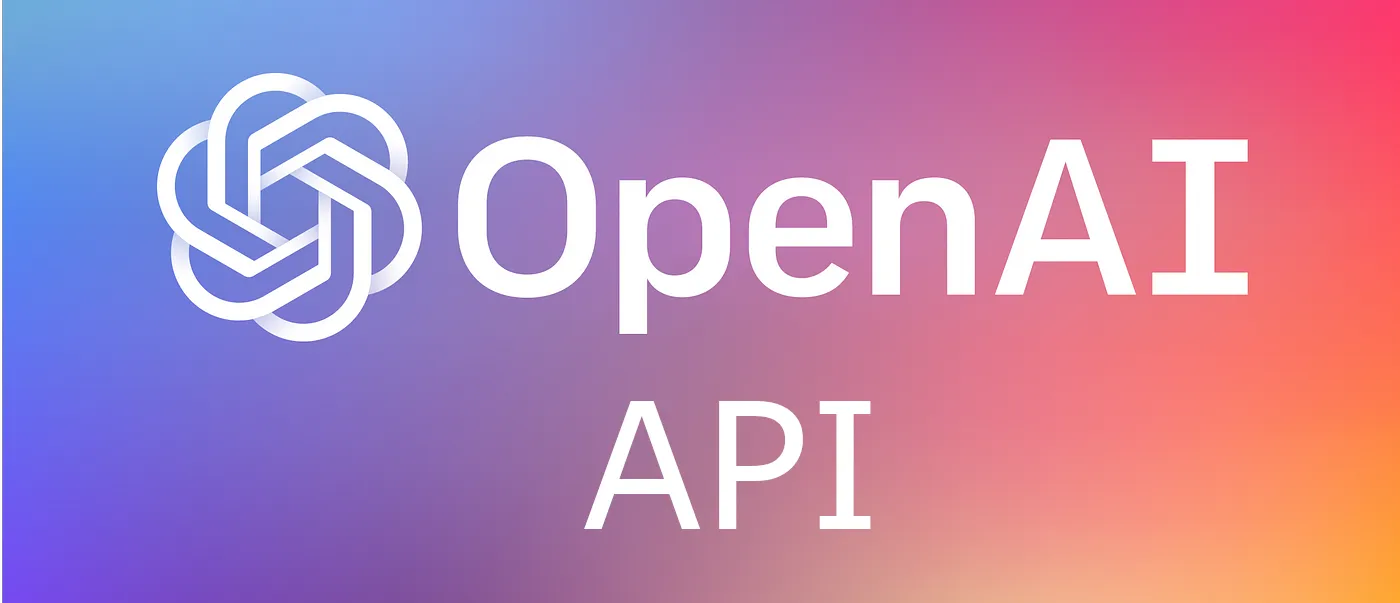

Welcome to this basic tutorial on using the OpenAI API in a Jupyter Notebook. We'll cover text generation, image generation, text-to-speech, speech-to-text, and asking questions about a Pandas DataFrame.

> **Useful links:** [Available models](https://platform.openai.com/docs/models) · [Pricing (pay-per-token/request)](https://openai.com/api/pricing/) · [Get an API key](https://platform.openai.com/api-keys)

First, you'll need to install the OpenAI Python library. You can do that by running the following command in a Jupyter Notebook cell:

In [ ]:
%pip install --upgrade openai

In [ ]:
from openai import OpenAI

Before using the OpenAI API, you'll need an API key. You can get one from [platform.openai.com/api-keys](https://platform.openai.com/api-keys) (requires an OpenAI account with billing set up). You can set it like this:

In [ ]:
import os

# Replace 'your-api-key' with your real API key
os.environ['OPENAI_API_KEY'] = 'your-api-key'

**Note:** Remember to replace `'your-api-key'` with your real API key. Keep your API key private and never share it or commit it to a public repository (treat it like a password).

> **Tip:** in a real project, avoid hardcoding the key in the notebook. Instead, store it in a `.env` file (ignored by git) and load it with `python-dotenv`, or set it as a system environment variable.

Now that we've set our API key, we can use the OpenAI API to generate text. Here's an example:

In [ ]:
client = OpenAI()

# gpt-4o-mini is a fast, low-cost model — good for class demos. See the models link above for other options.
completion = client.chat.completions.create(
  model="gpt-4o-mini",
  messages=[
    {"role": "system", "content": "You are a poetic assistant, skilled in explaining complex programming concepts with creative flair."},
    {"role": "user", "content": "Compose a poem that explains the concept of recursion in programming."}
  ]
)

print(completion.choices[0].message)

And that's it! You should now be able to use the OpenAI API to generate text in a Jupyter Notebook. Feel free to experiment with different values for `messages`, `temperature`, and `max_tokens` to see how they affect the generated text.

## Image generation with OpenAI

In [ ]:
import base64
from openai import OpenAI
client = OpenAI()

response = client.images.generate(
  model="gpt-image-1",
  prompt="A photo of a cat made out of sushi",
  size="1024x1024",
  n=1,
)

# Save the generated image to a file
image_bytes = base64.b64decode(response.data[0].b64_json)
with open("sushi_cat2.png", "wb") as image_file:
    image_file.write(image_bytes)
print("Saved sushi_cat.png")

In [ ]:
import base64
from openai import OpenAI
client = OpenAI()

response = client.images.generate(
  model="gpt-image-1",
  prompt="A monkey on a skateboard in space eating pizza",
  size="1024x1024",
  n=1,
)

image_bytes = base64.b64decode(response.data[0].b64_json)
with open("space_monkey.png", "wb") as image_file:
    image_file.write(image_bytes)
print("Saved space_monkey.png")

## Text-to-speech with OpenAI

> Check current [pricing](https://openai.com/api/pricing/) for image and audio models — they're billed differently from text models (per image / per audio minute).

In [ ]:
from openai import OpenAI

client = OpenAI()

response = client.audio.speech.create(
    model="tts-1",
    voice="alloy",
    input="We are learning how to use OpenAI's models to integrate them into our projects.",
)

response.stream_to_file("outputTTSalloy.mp3")

## Speech-to-text with OpenAI

In [ ]:
from openai import OpenAI
client = OpenAI()

# Reuses the file generated in the previous cell
audio_file = open("outputTTSalloy.mp3", "rb")
transcription = client.audio.transcriptions.create(
  model="whisper-1", 
  file=audio_file
)
print(transcription.text)

## Asking questions to a Pandas DataFrame

In [ ]:
import pandas as pd

# Import the 'mall_customers.csv' file (path relative to the workspace's Datasets folder)
df = pd.read_csv('/Users/eugenio/Documents/ArtificialIntelligence/Datasets/mall_customers.csv')

# Convert the table to a string representation
df_string = df.to_string()

# Question about the customers in the table
#question = "How would you design a marketing campaign to make the High Income-Low Spending segment increase its spending score?"
question = "Split customers by age. Which marketing channels would be most effective to reach each group?"
#question = "Which gender should I allocate more advertising resources to, considering their representation in the dataset?"

# Pass the data and question to the OpenAI API
client = OpenAI()
response = client.chat.completions.create(
    model="gpt-4o-mini",
    messages=[
        {"role": "system", "content": "You are a data analyst. Here is the data:\n" + df_string},
        {"role": "user", "content": question}
    ]
)

# Get the API's answer
answer = response.choices[0].message.content
print(answer)

That's it — now you can try OpenAI in your own code. Good luck!

# Activity: Building a Simple Chatbot with Streamlit and Hugging Face or OpenAI Models

## Objective
Students will build an interactive web app using **Streamlit** to create a simple chatbot. The chatbot will use a pretrained model from **Hugging Face** or **OpenAI** to generate responses based on the user's text prompts. The app should accept different kinds of input, such as free text or a data table.

## Instructions

1. **Install dependencies:**
   - Install Streamlit, OpenAI and the required libraries:
     ```bash
     pip install streamlit openai transformers pandas
     ```

2. **Build the app with Streamlit:**
   - Create a simple UI that lets the user enter text or upload a data table as input.
   - Integrate a **Hugging Face** model (`transformers`) or an **OpenAI** model so the chatbot can process the input and generate a response.

3. **Data input:**
   - Users should be able to enter a **text prompt** or **upload a table (CSV)** as input. If a table is uploaded, the chatbot should be able to answer questions about the data provided.
   - Use Streamlit to create text fields and a file upload option.

4. **Model interaction:**
   - Connect the user's input to a **Hugging Face** model (e.g. via `transformers`) or an **OpenAI** model (e.g. `gpt-4o-mini`).
   - If a table was uploaded, process it so the model can generate answers based on the data.

5. **Chatbot output:**
   - Display the model's response on the same page of the app.

6. **Tests:**
   1. The app works correctly and the model generates useful responses from the given inputs (the dataset and the user's prompt).
   2. The app does not answer questions that fall outside the scope of the dataset.

## Deliverables:
- The app's code as a Python file uploaded to Moodle, plus a link to the app published on **Streamlit Cloud**.
- A short presentation of the results in class.

## Evaluation criteria:
- The chatbot works correctly.
- Simple and clear user interface.
- Proper use of the AI model (Hugging Face or OpenAI).
- Correct use of Streamlit to build the interactive app.

## References:

- [Hugging Face models](https://huggingface.co/models)
- [OpenAI platform / API keys](https://platform.openai.com/api-keys)
- [OpenAI models](https://platform.openai.com/docs/models)

- [OpenAI pricing](https://openai.com/api/pricing/)- [Streamlit: build conversational apps](https://docs.streamlit.io/develop/tutorials/llms/build-conversational-apps)